## Random Forest: Predicting Salary (USD)

This notebook trains a Random Forest regressor on the cleaned dataset `salaries_cleaned.csv`.
It includes preprocessing, training, evaluation, and saving the model.

In [3]:
!pip install scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 1.0 MB/s  0:00:08m0:00:0100:010m━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.6 MB ? eta -:--:--
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 1.0 MB/s  0:00:08
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/20.9 MB ? eta -:--:--Downloading scipy-1.16.3-cp313-cp313-macosx_14_0_arm64.whl (20.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 1.3 MB/s  0:00:16m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 1.3 MB/s  0:00:16
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━

In [5]:
!pip install matplotlib seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.1 MB ? eta -:--:--Downloading matplotlib-3.10.7-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 836.6 kB/s  0:00:09 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (29

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [3]:
# Load cleaned data
data = pd.read_csv('../salaries_cleaned.csv')
print(f'Data shape: {data.shape}')
data.head()

Data shape: (52412, 9)


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Other,69120,NL,0,NL,M
1,2025,EN,FT,Other,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,US,0,US,M


In [4]:
# 1) Group rare job titles and frequency-encode
# Keep top-N frequent job titles, label rest 'Other' to reduce cardinality
top_n = 30
top_jobs = data['job_title'].value_counts().nlargest(top_n).index
data['job_title_grouped'] = data['job_title'].where(data['job_title'].isin(top_jobs), 'Other')
# Frequency encoding based on grouped job title (global freq)
job_freq = data['job_title_grouped'].value_counts(normalize=True)
data['job_title_freq'] = data['job_title_grouped'].map(job_freq)

# 2) Log-transform the target to reduce skew (we will invert predictions later)
data['salary_log'] = np.log1p(data['salary_in_usd'])

print('Created job_title_grouped (top', top_n, ') and job_title_freq; added salary_log target')
data[['job_title', 'job_title_grouped', 'job_title_freq', 'salary_in_usd', 'salary_log']].head()

Created job_title_grouped (top 30 ) and job_title_freq; added salary_log target


,job_title,job_title_grouped,job_title_freq,salary_in_usd,salary_log
0,Other,Other,0.187705,69120,11.143614
1,Other,Other,0.187705,50160,10.822993
2,Data Engineer,Data Engineer,0.107266,158113,11.971072
3,Data Engineer,Data Engineer,0.107266,87795,11.382771
4,Data Engineer,Data Engineer,0.107266,351410,12.769712


In [5]:
# Feature selection (use log-transformed target and job_title frequency encoding)
# Target: salary_log (log1p of salary_in_usd)
target = 'salary_log'
# Choose features; use job_title_freq (numeric) instead of raw job_title
features = [
    'work_year',
    'experience_level',
    'employment_type',
    'job_title_freq',
    'employee_residence',
    'remote_ratio',
    'company_location',
    'company_size'
]
X = data[features].copy()
y = data[target].copy()
print('Features used:', features)
print('X shape:', X.shape, 'y shape:', y.shape)

Features used: ['work_year', 'experience_level', 'employment_type', 'job_title_freq', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
X shape: (52412, 8) y shape: (52412,)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Preprocessing: One-hot encode categorical features, keep numeric as-is
# We use job_title_freq (numeric) instead of raw job_title to reduce cardinality
categorical_features = [
    'experience_level', 'employment_type',
    'employee_residence', 'company_location', 'company_size'
]
numeric_features = ['work_year', 'remote_ratio', 'job_title_freq']

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe = Pipeline([
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_features),
        ('num', num_pipe, numeric_features)
    ],
    remainder='drop'
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (41929, 8) Test shape: (10483, 8)


In [7]:
# Build pipeline with Random Forest Regressor (we will tune hyperparameters)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', rf)
])

# Hyperparameter tuning using RandomizedSearchCV (tune a few important params)
from sklearn.model_selection import RandomizedSearchCV
import time
param_dist = {
    'regressor__n_estimators': [100, 200, 400],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__max_features': ['sqrt', 'log2']
}
rand_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20,
                                 scoring='neg_mean_squared_error', cv=3, verbose=2, n_jobs=-1, random_state=42)
start = time.time()
rand_search.fit(X_train, y_train)
end = time.time()
print(f'RandomizedSearchCV done in {end-start:.1f}s')
print('Best params:', rand_search.best_params_)
# use best estimator as our final pipeline
pipeline = rand_search.best_estimator_
print('Best pipeline ready.')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   4.0s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   4.0s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   4.0s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   4.0s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   4.0s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   4.0s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor

In [9]:
# Predictions and evaluation
# pipeline predicts the log-target (salary_log). Invert with expm1 to get original USD scale
y_pred_log = pipeline.predict(X_test)
# invert log transform for both predictions and true values
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = mse ** 0.5
r2 = r2_score(y_test_orig, y_pred_orig)

print(f'MAE: {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R^2: {r2:.4f}')

# Show a small comparison table (original scale)
comp = pd.DataFrame({
    'actual_usd': y_test_orig,
    'predicted_usd': y_pred_orig
})
comp.reset_index(drop=True, inplace=True)
comp.head(10)


MAE: 47,106.59
RMSE: 67,642.97
R^2: 0.2519


,actual_usd,predicted_usd
0,89000.0,128745.190520
1,123365.0,128745.190520
2,46160.0,93768.773733
3,167981.0,154905.917940
4,67725.0,93538.107130
5,231100.0,194504.136405
6,175600.0,160390.598178
7,97300.0,127399.724631
8,98300.0,171006.625176
9,61781.0,57606.874057


In [10]:
# Feature importances (map back to column names)
pre = pipeline.named_steps['preprocessor']
# get feature names from the ColumnTransformer and OneHotEncoder
try:
    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(categorical_features)
    num_names = numeric_features
    feature_names = list(cat_names) + list(num_names)
except Exception:
    feature_names = None

# extract importances from the fitted RandomForestRegressor
rf_model = pipeline.named_steps['regressor']
importances = rf_model.feature_importances_

if feature_names is not None and len(feature_names) == len(importances):
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
else:
    feat_imp = pd.DataFrame({'feature': [f'f{i}' for i in range(len(importances))], 'importance': importances})

feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
feat_imp.head(30)

,feature,importance
0,job_title_freq,0.251776
1,experience_level_EN,0.126113
2,experience_level_SE,0.094648
3,employee_residence_US,0.093076
4,company_location_US,0.087333
5,experience_level_MI,0.037818
6,experience_level_EX,0.028077
7,work_year,0.024628
8,employee_residence_CA,0.019121
9,company_location_GB,0.018574


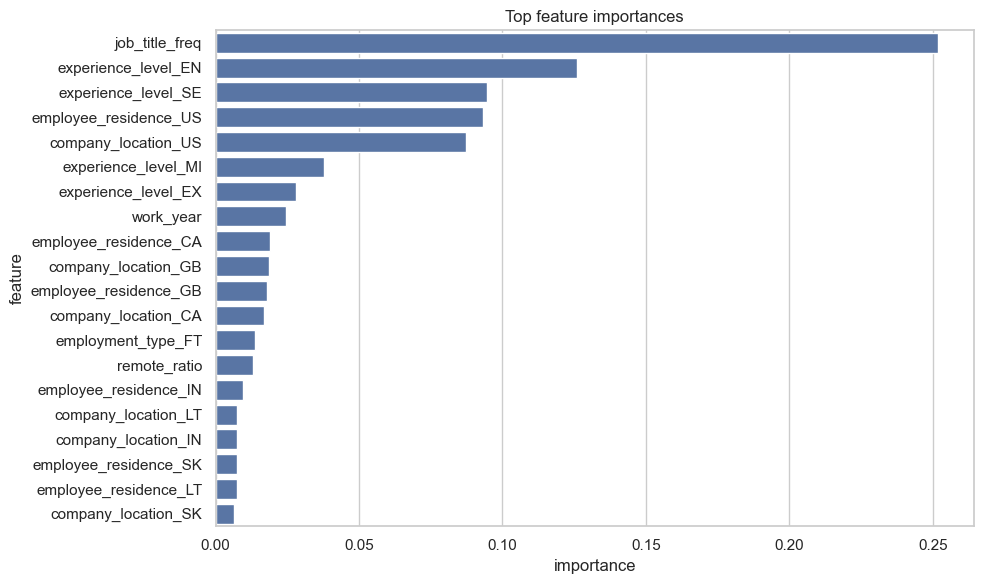

In [11]:
# Plot top 20 feature importances
top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(top_n))
plt.title('Top feature importances')
plt.tight_layout()
plt.show()

In [12]:
# Save trained pipeline to disk
model_path = 'rf_salary_pipeline.joblib'
joblib.dump(pipeline, model_path)
print(f'Model pipeline saved to: {model_path}')

Model pipeline saved to: rf_salary_pipeline.joblib
